In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
!pip install captum

In [ ]:
def clean():
    import gc
    import torch
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

import os
import torch
import models #type: ignore
import blosc2
import shutil
import importlib
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm
import torch.nn as nn
from copy import deepcopy
from scipy.stats import mode,zscore,ttest_1samp
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from IPython.display import clear_output
from IntegratedGradient import IntegratedGradient #type: ignore
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)

In [ ]:
def min_max_scale(X, min_max_range=(0,1)):
    min = min_max_range[0]
    max = min_max_range[1]
    if not isinstance(X, np.ndarray):
        X = X.numpy()
    X_std = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))
    X_scaled = X_std * (max - min) + min
    return X_scaled

def chunk_and_reshape(spikes, lfp, seqlength, test_size=0.2, prediction_lag = 0, random_state=42):
    if len(lfp.shape) == 1:
        lfp = lfp[:, np.newaxis]
    if prediction_lag > 0:
        lfp_shifted = np.roll(lfp, -prediction_lag, axis=0)
        lfp_shifted = lfp_shifted[:-prediction_lag, :]
        spikes = spikes[:-prediction_lag, :]
    else:
        lfp_shifted = lfp
    num_trials = int(lfp_shifted.shape[0] / seqlength)
    if spikes.shape[0] % seqlength != 0:
        spikes = spikes[:-(spikes.shape[0] % seqlength), :]
        lfp_shifted = lfp_shifted[:-(lfp_shifted.shape[0] % seqlength), :]
    X_reshaped = torch.reshape(spikes, (num_trials, seqlength, spikes.shape[1]))
    lfp_reshaped = torch.reshape(lfp_shifted, (num_trials, seqlength, lfp_shifted.shape[1]))
    X_train, X_test, y_train, y_test = train_test_split(
        X_reshaped, lfp_reshaped, test_size=test_size, random_state=random_state
    )
    return X_train, X_test, y_train, y_test

def get_data_loaders(X_train, X_test, y_train, y_test, batch_size, device):
    X_train.to(device)
    X_test.to(device)
    y_train.to(device)
    y_test.to(device)
    train_dataset = TensorDataset(X_train, y_train)
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_dataset = TensorDataset(X_test, y_test)
    test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_dataloader, test_dataloader

In [ ]:
spikes_src = "/content/drive/MyDrive/spike_1119946360_raw.b2"
spikes_dst = "/content/spikes.b2"
shutil.copy(spikes_src, spikes_dst)
spikes = blosc2.load_tensor(spikes_dst)
fr_instant = spikes.numpy().copy()
spikes  = min_max_scale(spikes)

lfp_src = "/content/drive/MyDrive/lfp_1119946360.b2"
lfp_dst = "/content/lfp.b2"
shutil.copy(lfp_src, lfp_dst)
lfp = blosc2.load_tensor(lfp_dst)

sp = pd.read_csv("/content/drive/MyDrive/sp_1119946360.csv")
df = pd.read_csv("/content/drive/MyDrive/units_info.csv",index_col=0)
units = pd.read_csv('/content/drive/MyDrive/units_1119946360.csv')
channels = pd.read_csv("/content/drive/MyDrive/channels_1119946360.csv")
timestamps = np.load("/content/drive/MyDrive/timestamps_1119946360.npy")

attrs_src = "/content/drive/MyDrive/spk2lfp/attrs/1119946360/attrs_channel_5_band_0.b2"
attrs_dst = "/content/attrs.b2"
shutil.copy(attrs_src, attrs_dst)
attrs = blosc2.load_tensor(attrs_dst)
attrs = attrs.numpy()

In [ ]:
seqlength = 750
chani = 5
bandi = 0
batch_size = 32
device = 'cuda'
input_size = spikes.shape[-1]
hidden_size = 50
num_layers = 1
num_epochs = 15
criterion = nn.MSELoss()

In [ ]:
# find 10 VIS units with the highest mean abs attrs scores
attrs_avg = np.mean(np.abs(attrs), axis=0)
vis_filter = units.structure_acronym.str.contains("VIS")
attrs_avg_vis = attrs_avg[vis_filter]
attrs_avg_vis_idx = np.argsort(attrs_avg_vis)[-10:]
vis_units = units[vis_filter]
top_vis_units = vis_units.iloc[attrs_avg_vis_idx]

# find the median population fr in area of each unit
top_areas = np.unique(top_vis_units.structure_acronym.values)
area_fr = {}
for area in top_areas:
    units_area_all = units.structure_acronym.values == area
    area_fr[area] = int(np.median(np.sum(fr_instant[:, units_area_all], axis=0)))

In [ ]:
area_fr

{'VISal': 7223, 'VISp': 9559, 'VISpm': 10672}

In [ ]:
# randomly subsample
def subsample_spike_train(spk, target):
    if not isinstance(spk, np.ndarray):
        spk = spk.numpy()
    spk_idx = np.flatnonzero(spk).astype(int) # get indices of non-zero spikes
    spk_counts = spk[spk_idx].astype(int) # count the number of spikes at each index
    idx_expanded = np.repeat(spk_idx, spk_counts) # expand indices according to counts (count of 2 means the index appears twice)
    idx_subsampled = np.random.choice(idx_expanded, size=target, replace=False) # randomly choose indices from the expanded list
    spk_subsampled = np.zeros_like(spk) 
    np.add.at(spk_subsampled, idx_subsampled, 1) # add 1 to the indices in the subsampled array
    return spk_subsampled

# subsample chunks
# Only keep a continuous chunk of spikes that meets the target, zero out the rest
# Logic: find the first chunk, then move the end point rightward first, and see if we can move the start point rightward 
def find_chunks(arr, target):
    index_set = []
    if np.sum(arr) < target:
        print("The entire arr does not meet target")
        return index_set
    non_zero = np.flatnonzero(arr)
    # find the first end point
    # i.e. starting from t=0, find the first time point that meets the target
    current_sum = 0
    for idx, i in enumerate(non_zero):
        current_sum += arr[i]
        if current_sum >= target:
            end_point = i
            end_point_idx = idx
            index_set.append([non_zero[0], end_point])
            break
    if end_point_idx == len(non_zero) - 1: return index_set
    # starting from the next end-point, go backward and find the start idx
    start_point_idx = 0
    for i in tqdm(range(end_point_idx+1, len(non_zero), 1)): # start from the next end point til the end of arr
        end_point = arr[non_zero[i]]
        start_point = arr[non_zero[start_point_idx]]
        if current_sum + end_point - start_point >= target: # the next end point is enough to meet the target without the start point
            current_sum = current_sum + end_point - start_point
            start_point_idx += 1 # move the start point forward
            while (current_sum - target) >= arr[non_zero[start_point_idx]]: # if current sum exceeds target, keep moving the start point forward
                current_sum -= arr[non_zero[start_point_idx]]
                start_point_idx += 1
            index_set.append([non_zero[start_point_idx], non_zero[i]]) # now we have a new chunk
        else:
            current_sum = current_sum + end_point # if the next end point if not enough to meet the target, just add it to the current sum and don't move the start point
            index_set.append([non_zero[start_point_idx], non_zero[i]])
    return index_set

In [ ]:
#@title Subsampling spikes
if os.path.exists('/content/attrs') == False:
    os.mkdir('/content/attrs')

chani=5
bandi=0
lfp_selected = lfp[:,chani,bandi]
spikes = torch.tensor(spikes).float()
# find top units to subsample
top_vis_units_ids = top_vis_units.id.values
top_vis_units_idx = np.arange(len(units))[np.isin(units.id.values, top_vis_units_ids)]

num_iter = 100
r2_scores = np.zeros(num_iter)

for i in range(num_iter):
    clear_output(wait=True)
    print(f"Subsampling round {i}")
    X = torch.tensor(fr_instant.copy()).float() # fr_instant is spikes before min_max
    for id, idx in zip(top_vis_units_ids, top_vis_units_idx):
        unit_population_fr = int(area_fr[units[units.id.values==id].structure_acronym.values[0]]) # find median fr in area
        unit_spk = X[:,idx] 
        unit_spk_subsampled = subsample_spike_train(unit_spk, unit_population_fr)
        X[:,idx] = torch.tensor(unit_spk_subsampled).float() # replace the original spike train with the subsampled one
    X = torch.tensor(min_max_scale(X)).float() # then min max
    X_train, X_test,y_train, y_test = chunk_and_reshape(X, lfp_selected, seqlength)
    train_dataloader, test_dataloader = get_data_loaders(X_train,X_test,y_train,y_test,batch_size,device)
    model = models.process_model(models.LSTMnet(input_size=input_size,
                                                num_hidden=hidden_size,
                                                num_layers=num_layers,
                                                seqlength=seqlength
                                                ),criterion, device)
    train_loss, test_loss = model.train(train_dataloader, test_dataloader , num_epochs)
    y_test_flat = y_test.reshape(y_test.shape[0]*y_test.shape[1]*y_test.shape[2])
    yHat = model.evaluate(test_dataloader.dataset.tensors[0])
    r2_scores[i] = r2_score(yHat.cpu(), y_test_flat)
    print(r2_scores[i])

    method='last time point'
    attr_dur = 720
    bin_size = 0.004
    seqlength = 750
    num_bins = int(attr_dur/bin_size)
    X_attr = X[:num_bins,:].to(device)
    num_trials = int(num_bins/seqlength)
    X_attr = X_attr.reshape(num_trials, seqlength, X_attr.shape[1])

    ig = IntegratedGradient(model.model.train().to(device), method=method)
    attrs = ig.run(X_attr,
                    baselines=0,
                    n_batch=40,
                    n_steps=50)
    blosc2.save_tensor(attrs, f"/content/attrs/attrs_channel_5_band_0_subsample_{i}.b2")
np.save("/content/r2_scores.npy", r2_scores)

Subsampling round 99
0.714209601129978


100%|██████████| 8/8 [00:13<00:00,  1.73s/it]


In [ ]:
#@title Subsampling chunks
if os.path.exists('/content/attrs') == False:
    os.mkdir('/content/attrs')

chani=5
bandi=0
lfp_selected = lfp[:,chani,bandi]
# find top units to subsample
top_vis_units_ids = top_vis_units.id.values
top_vis_units_idx = np.arange(len(units))[np.isin(units.id.values, top_vis_units_ids)]
num_iter = 10
qualified_indices = {}
# iterate through each unit, and find the right chunks
for id, idx in zip(top_vis_units_ids, top_vis_units_idx):
    unit_population_fr = int(area_fr[units[units.id.values==id].structure_acronym.values[0]])
    unit_spk = fr_instant[:,idx]
    unit_spk_chunk_idx = np.array(find_chunks(unit_spk, unit_population_fr)) # find all chunks that meet the target
    idx_to_choose = np.arange(len(unit_spk_chunk_idx))
    idx_chosen = np.random.choice(idx_to_choose, size=num_iter, replace=False) # shuffle the chunks and pick only num_iter chunks for each unit
    random_idx = unit_spk_chunk_idx[idx_chosen]
    qualified_indices[id] = random_idx

r2_scores = np.zeros(num_iter)

for i in range(num_iter):
    clear_output(wait=True)
    print(f"Subsampling round {i}")
    X = torch.tensor(fr_instant.copy()).float()
    for idx, id in enumerate(list(qualified_indices.keys())):
        unit_spk_chunk_idx = qualified_indices[id]
        unit_spk = X[:,idx]
        mask = torch.zeros_like(unit_spk)
        start_idx = unit_spk_chunk_idx[i][0]
        end_idx = unit_spk_chunk_idx[i][1]
        mask[start_idx:end_idx] = 1
        X[:,idx] = (unit_spk*mask).float()
    X = torch.tensor(min_max_scale(X)).float()
    X_train, X_test,y_train, y_test = chunk_and_reshape(X, lfp_selected, seqlength)
    train_dataloader, test_dataloader = get_data_loaders(X_train,X_test,y_train,y_test,batch_size,device)
    model = models.process_model(models.LSTMnet(input_size=input_size,
                                                num_hidden=hidden_size,
                                                num_layers=num_layers,
                                                seqlength=seqlength
                                                ),criterion, device)
    train_loss, test_loss = model.train(train_dataloader, test_dataloader , num_epochs)
    y_test_flat = y_test.reshape(y_test.shape[0]*y_test.shape[1]*y_test.shape[2])
    yHat = model.evaluate(test_dataloader.dataset.tensors[0])
    r2_scores[i] = r2_score(yHat.cpu(), y_test_flat)
    print(r2_scores[i])
    method='last time point'
    attr_dur = 720
    bin_size = 0.004
    seqlength = 750
    num_bins = int(attr_dur/bin_size)
    X_attr = X[:num_bins,:].to(device)
    num_trials = int(num_bins/seqlength)
    X_attr = X_attr.reshape(num_trials, seqlength, X_attr.shape[1])

    ig = IntegratedGradient(model.model.train().to(device), method=method)
    attrs = ig.run(X_attr,
                    baselines=0,
                    n_batch=40,
                    n_steps=50)
    blosc2.save_tensor(attrs, f"/content/attrs/attrs_channel_5_band_0_subsample_{i}.b2")
np.save("/content/r2_scores.npy", r2_scores)

Subsampling round 9


<ipython-input-16-435b65747ea0>:37: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X[:,idx] = torch.tensor(unit_spk*mask).float()


0.7515219355050361


100%|██████████| 8/8 [00:13<00:00,  1.71s/it]


In [ ]:
# Baseline case, not subsampled
if isinstance(spikes, np.ndarray): spikes = torch.tensor(spikes).float()
X_train, X_test,y_train, y_test = chunk_and_reshape(spikes, lfp_selected, seqlength)
train_dataloader, test_dataloader = get_data_loaders(X_train,X_test,y_train,y_test,batch_size,device)
model = models.process_model(models.LSTMnet(input_size=input_size,
                                            num_hidden=hidden_size,
                                            num_layers=num_layers,
                                            seqlength=seqlength
                                            ),criterion, device)
train_loss, test_loss = model.train(train_dataloader, test_dataloader , num_epochs)
y_test_flat = y_test.reshape(y_test.shape[0]*y_test.shape[1]*y_test.shape[2])
yHat = model.evaluate(test_dataloader.dataset.tensors[0])
print(r2_score(yHat.cpu(), y_test_flat))

X_attr = spikes[:num_bins,:].to(device)
num_trials = int(num_bins/seqlength)
X_attr = X_attr.reshape(num_trials, seqlength, X_attr.shape[1])

ig = IntegratedGradient(model.model.train().to(device), method=method)
attrs = ig.run(X_attr,
                baselines=0,
                n_batch=40,
                n_steps=50)
attrs = attrs.reshape((attrs.shape[0]*attrs.shape[1],attrs.shape[2]))

0.7438429015616729


100%|██████████| 8/8 [00:13<00:00,  1.70s/it]


In [ ]:
blosc2.save_tensor(attrs, "/content/attrs/attrs_channel_5_band_0_unsubsampled.b2")

87785061

In [ ]:
shutil.copytree('/content/attrs', '/content/drive/MyDrive/spk2lfp/attrs/1119946360_subsampled')

'/content/drive/MyDrive/spk2lfp/attrs/1119946360_subsampled'

In [ ]:
top_vis_unit_attrs_change = np.zeros((10, 11)) # for each of the 10 units, find the change in attrs in each 10 subsamplings 
avg_attrs_change = np.zeros(11) # find the average in each subsampling
top_vis_unit_attrs_change[:,0] = attrs_avg_vis[attrs_avg_vis_idx] # baseline case, not subsampled
avg_attrs_change[0] = torch.mean(torch.mean(torch.abs(attrs), axis=0)[vis_filter]) # the average of all 10 units, just for the sake of easy comparison

for i in range(1,11):
    # attrs_src = f"/content/drive/MyDrive/spk2lfp/attrs/1119946360_subsampled/attrs_channel_5_band_0_subsample_{i-1}.b2"
    attrs_dst = f"/content/attrs/attrs_channel_5_band_0_subsample_{i-1}.b2"
    # shutil.copy(attrs_src, attrs_dst)
    attrs_sumsampled = blosc2.load_tensor(attrs_dst)
    attrs_sumsampled = attrs_sumsampled.numpy()
    attrs_avg_sumsampled = np.mean(np.abs(attrs_sumsampled), axis=0)[vis_filter]
    top_vis_unit_attrs_change[:,i] = attrs_avg_sumsampled[attrs_avg_vis_idx]
    avg_attrs_change[i] = np.mean(np.mean(np.abs(attrs_sumsampled), axis=0)[vis_filter])

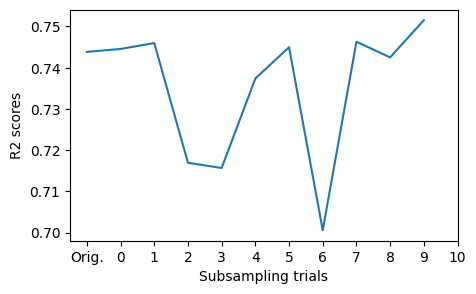

In [ ]:
r2_scores = np.load("/content/r2_scores.npy")
full_model_r2 = r2_score(yHat.cpu(), y_test_flat)
r2_scores = np.append(full_model_r2, r2_scores)
fig = plt.figure(figsize=(5,3))
plt.plot(r2_scores)
xticks = np.append(np.array(['Orig.']), np.arange(-1,11,1)[1:])
plt.ylabel("R2 scores")
plt.xticks(np.arange(0,12,1), xticks)
plt.xlabel("Subsampling trials");

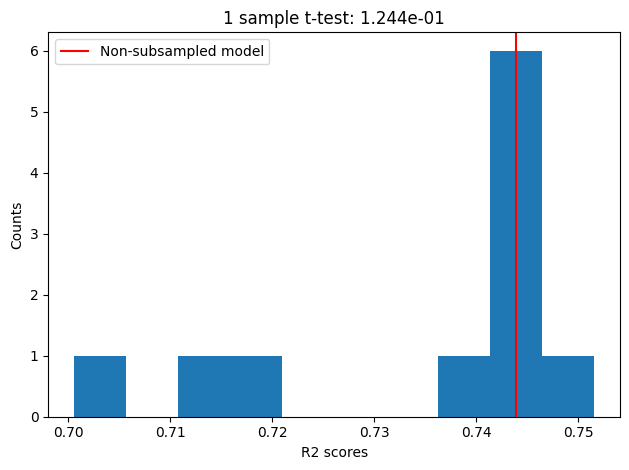

In [ ]:
plt.hist(r2_scores);
plt.axvline(full_model_r2, c='r', label='Non-subsampled model')
plt.xlabel("R2 scores")
plt.ylabel("Counts")
plt.title(f"1 sample t-test: {ttest_1samp(r2_scores, full_model_r2).pvalue:.3e}")
plt.legend()
plt.tight_layout()
plt.show();

In [ ]:
# for the three areas that we find, get the units from that area
# compare units only to their own area, not to the entire average
attrs_subsampled_each_area = np.zeros((4,11))
attrs_subsampled_each_area_std = np.zeros((4,11))
from tqdm import tqdm
for i in tqdm(range(0,11)):
    if i == 0:
        attrs_subsampled_avg = np.mean(np.abs(np.array(attrs)), axis=0)
    else:
        attrs_subsampled = np.array(blosc2.load_tensor(f"/content/attrs/attrs_channel_5_band_0_subsample_{i-1}.b2"))
        attrs_subsampled_avg = np.mean(np.abs(attrs_subsampled), axis=0)
    for idx, area in enumerate(top_areas):
        units_area_all = units.structure_acronym.values == area
        attrs_subsampled_avg_area = np.mean(attrs_subsampled_avg[units_area_all])
        attrs_subsampled_each_area[idx,i] = attrs_subsampled_avg_area
        attrs_subsampled_each_area_std[idx,i] = np.std(attrs_subsampled_avg[units_area_all])

100%|██████████| 11/11 [00:22<00:00,  2.06s/it]


In [ ]:
np.savez("/content/top_vis_units_attrs_stats.npz", area_mean=attrs_subsampled_each_area, area_names=top_areas, area_std=attrs_subsampled_each_area_std)
shutil.copy("/content/top_vis_units_attrs_stats.npz", "/content/drive/MyDrive/spk2lfp/attrs/1119946360_subsampled/top_vis_units_attrs_stats.npz")

'/content/drive/MyDrive/spk2lfp/attrs/1119946360_subsampled/top_vis_units_attrs_stats.npz'

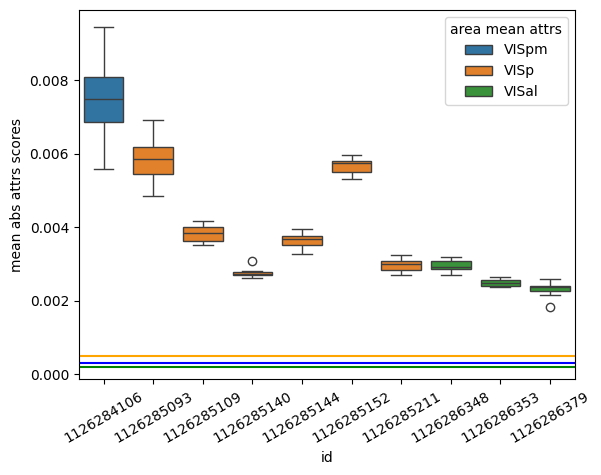

In [ ]:
reference_ids = np.array([])
for idx, area in enumerate(top_areas):
    top_vis_units_idx = top_vis_units.structure_acronym.values==area
    top_vis_units_ids = top_vis_units.id.values[top_vis_units_idx]
    reference_ids = np.append(reference_ids, top_vis_units_ids)

# reference_ids is the ids of the top 10 units
temp_df = units[np.isin(units.id.values, reference_ids)].copy(deep=True) # units df, but only for the top 10 units
attrs_change_df = pd.DataFrame(pd.Series(list(top_vis_unit_attrs_change[:,1:]), reference_ids), columns=['subsampling'])
temp_df = temp_df.merge(attrs_change_df, left_on='id', right_index=True)
temp_df = temp_df.reset_index(drop=True).set_index('id')
# create a dataframe with unit id, mean abs attrs scores of the unit, mean abs attrs of the area, area name 
long_df = pd.DataFrame([
    {'id': i, 'mean abs attrs scores': val, 'area mean attrs': temp_df.loc[i, 'structure_acronym']}
    for i in temp_df.index
    for val in temp_df.loc[i, 'subsampling']
])
# plot the mean abs attrs scores of the units in each area, color coded by area
# plot the avg mean abs attrs scores of the area as horizontal lines, color coded by area
sns.boxplot(x='id', y='mean abs attrs scores', hue='area mean attrs', data=long_df)
plt.xticks(rotation=30)
plt.axhline(np.mean(attrs_subsampled_each_area[0,1:]), label=top_areas[0], c='b')
plt.axhline(np.mean(attrs_subsampled_each_area[1,1:]), label=top_areas[1], c='orange')
plt.axhline(np.mean(attrs_subsampled_each_area[2,1:]), label=top_areas[2], c='g');